#### PROBLEM STATEMENT
Digital lenders in Nigeria face massive losses due to non-performing loans, made worse by severe class imbalance in applicant data, where defaulters are a small minority. When standard Machine Learning models are trained on such imbalanced data, they fall into the accuracy paradox: achieving high overall accuracy while almost entirely failing to detect actual defaulters(which is the very cases that matter most).

##### Why a Synthetic Dataset?

This project operates within Nigeria's digital lending and fintech space. Real loan applicant data including names, income, credit history, BVN, and employment details is classified as sensitive personal and financial information. The CBN Framework prohibits financial institutions from disclosing customers' personal information, and the Nigeria Data Protection Act(NDPA) mandates robust data protection, transparency, and user consent before any such data can be accessed or processed. This makes real world Nigerian loan default datasets legally inaccessible to independent researchers.

In line with standard data science practice for confidential financial domains, this project uses a synthetically generated dataset, purposefully designed to mirror the 88:12 class imbalance typical of Nigerian digital lenders, to practically demonstrate SMOTE based resampling and recall optimized ML pipelines, without breaching any data protection law.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Loan_default.csv")

In [3]:
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [4]:
df.columns

Index(['LoanID', 'Age', 'Income', 'LoanAmount', 'CreditScore',
       'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm',
       'DTIRatio', 'Education', 'EmploymentType', 'MaritalStatus',
       'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner',
       'Default'],
      dtype='object')

In [5]:
df.shape

(255347, 18)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  object 
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  object 
 11  EmploymentType  255347 non-null  object 
 12  MaritalStatus   255347 non-null  object 
 13  HasMortgage     255347 non-null  object 
 14  HasDependents   255347 non-null  object 
 15  LoanPurpose     255347 non-null  object 
 16  HasCoSigner     255347 non-null  object 
 17  Default   

#### Exploratory Data Analysis

In [7]:
df.isna().sum()

LoanID            0
Age               0
Income            0
LoanAmount        0
CreditScore       0
MonthsEmployed    0
NumCreditLines    0
InterestRate      0
LoanTerm          0
DTIRatio          0
Education         0
EmploymentType    0
MaritalStatus     0
HasMortgage       0
HasDependents     0
LoanPurpose       0
HasCoSigner       0
Default           0
dtype: int64

In [8]:
df.describe().T.round(4)

,count,mean,std,min,25%,50%,75%,max
Age,255347.0,43.4983,14.9903,18.0,31.00,43.00,56.00,69.0
Income,255347.0,82499.3046,38963.0137,15000.0,48825.50,82466.00,116219.00,149999.0
LoanAmount,255347.0,127578.8655,70840.7061,5000.0,66156.00,127556.00,188985.00,249999.0
CreditScore,255347.0,574.2643,158.9039,300.0,437.00,574.00,712.00,849.0
MonthsEmployed,255347.0,59.5420,34.6434,0.0,30.00,60.00,90.00,119.0
NumCreditLines,255347.0,2.5010,1.1170,1.0,2.00,2.00,3.00,4.0
InterestRate,255347.0,13.4928,6.6364,2.0,7.77,13.46,19.25,25.0
LoanTerm,255347.0,36.0259,16.9693,12.0,24.00,36.00,48.00,60.0
DTIRatio,255347.0,0.5002,0.2309,0.1,0.30,0.50,0.70,0.9
Default,255347.0,0.1161,0.3204,0.0,0.00,0.00,0.00,1.0


In [9]:
df['Default'].value_counts()

Default
0    225694
1     29653
Name: count, dtype: int64

In [10]:
(df['Default'].value_counts() / len(df) * 100)

Default
0    88.387175
1    11.612825
Name: count, dtype: float64

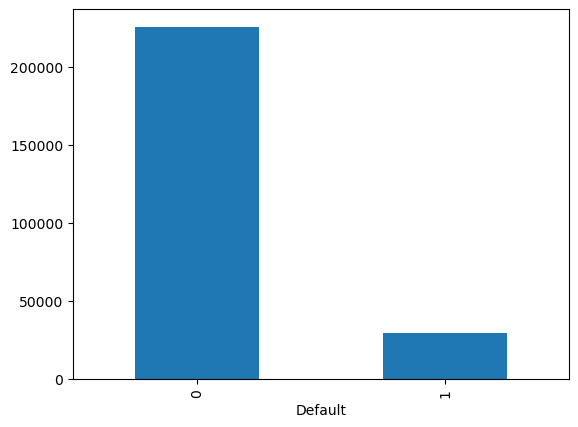

In [11]:
df['Default'].value_counts().plot(kind="bar");

#### Feature Engineering

In [12]:
#lOAN TO INCOME RATIO: It tends to measure the specific burden of the loan applicant against his or her salary
df['LTIRatio'] = df['LoanAmount'] / df['Income']

#AGE GROUP: It tends to capture non-linear age effect on default, 
#It can sometimes reveal generational default trends better than raw continuous numbers,while performing EDA
# Define the edges of your age groups
bins = [17, 30, 45, 60, 100]
# Define the names for those groups
labels = ['Young Adult', 'Adult', 'Middle-Aged', 'Senior/Retiree']

# Create the new column
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels, right=True)

In [13]:
df.sample(2)

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default,LTIRatio,AgeGroup
176894,5S6VXAUTA8,44,74753,176793,670,87,4,18.45,48,0.11,Bachelor's,Full-time,Married,Yes,No,Other,No,0,2.365029,Adult
10326,CVNHDHH9AY,69,114056,109360,454,54,4,20.51,60,0.76,High School,Unemployed,Married,No,No,Home,No,0,0.958827,Senior/Retiree


In [14]:
#Dropping LoanID due to the fact that is irrelevant and ddoes not contribute any predicitive power to the model at all

In [15]:
df.drop(columns=['LoanID'], inplace=True)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 19 columns):
 #   Column          Non-Null Count   Dtype   
---  ------          --------------   -----   
 0   Age             255347 non-null  int64   
 1   Income          255347 non-null  int64   
 2   LoanAmount      255347 non-null  int64   
 3   CreditScore     255347 non-null  int64   
 4   MonthsEmployed  255347 non-null  int64   
 5   NumCreditLines  255347 non-null  int64   
 6   InterestRate    255347 non-null  float64 
 7   LoanTerm        255347 non-null  int64   
 8   DTIRatio        255347 non-null  float64 
 9   Education       255347 non-null  object  
 10  EmploymentType  255347 non-null  object  
 11  MaritalStatus   255347 non-null  object  
 12  HasMortgage     255347 non-null  object  
 13  HasDependents   255347 non-null  object  
 14  LoanPurpose     255347 non-null  object  
 15  HasCoSigner     255347 non-null  object  
 16  Default         255347 non-null  int64

In [17]:
df['AgeGroup'] = df['AgeGroup'].astype('object')

In [18]:
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include = 'object').columns

In [19]:
num_cols.tolist()

['Age',
 'Income',
 'LoanAmount',
 'CreditScore',
 'MonthsEmployed',
 'NumCreditLines',
 'InterestRate',
 'LoanTerm',
 'DTIRatio',
 'Default',
 'LTIRatio']

In [20]:
cat_cols.tolist()

['Education',
 'EmploymentType',
 'MaritalStatus',
 'HasMortgage',
 'HasDependents',
 'LoanPurpose',
 'HasCoSigner',
 'AgeGroup']

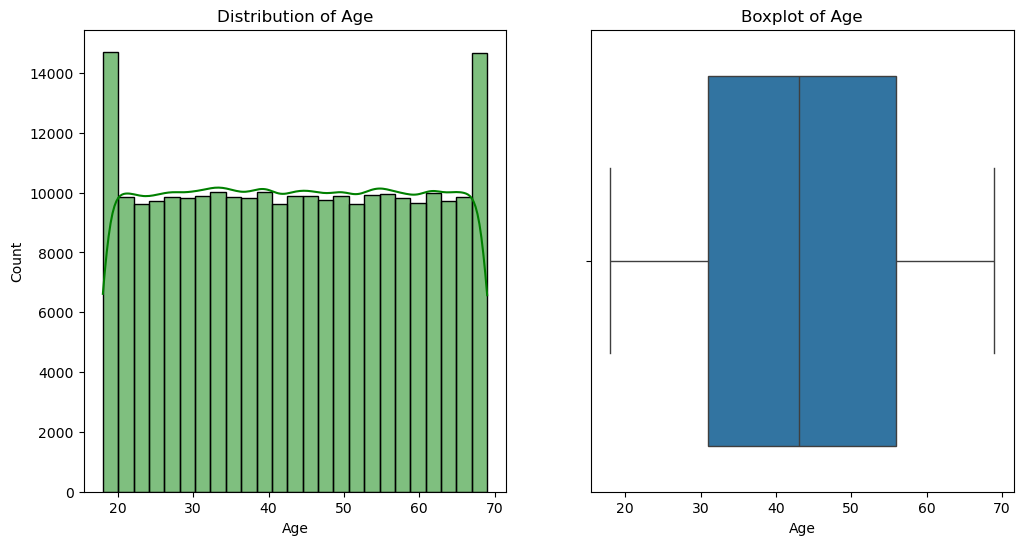

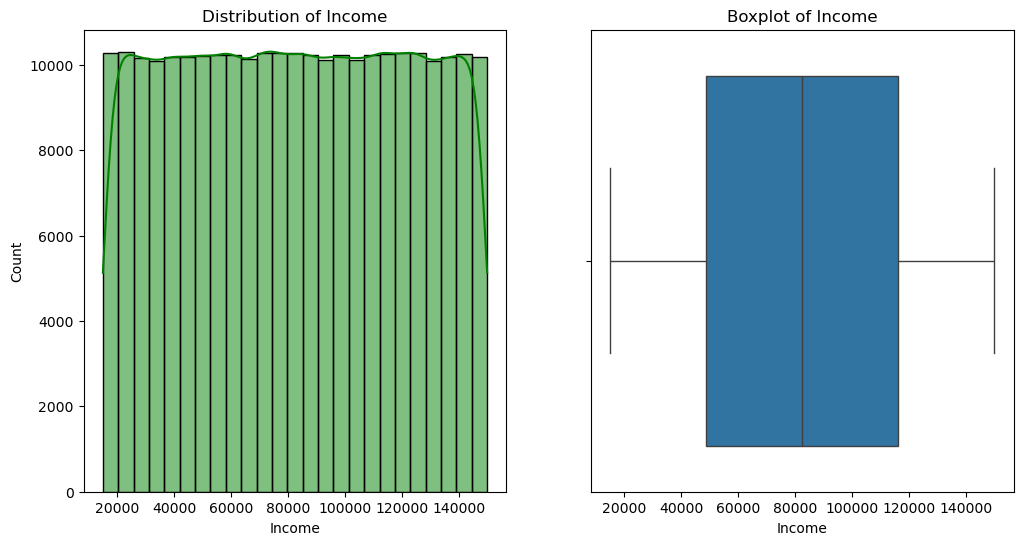

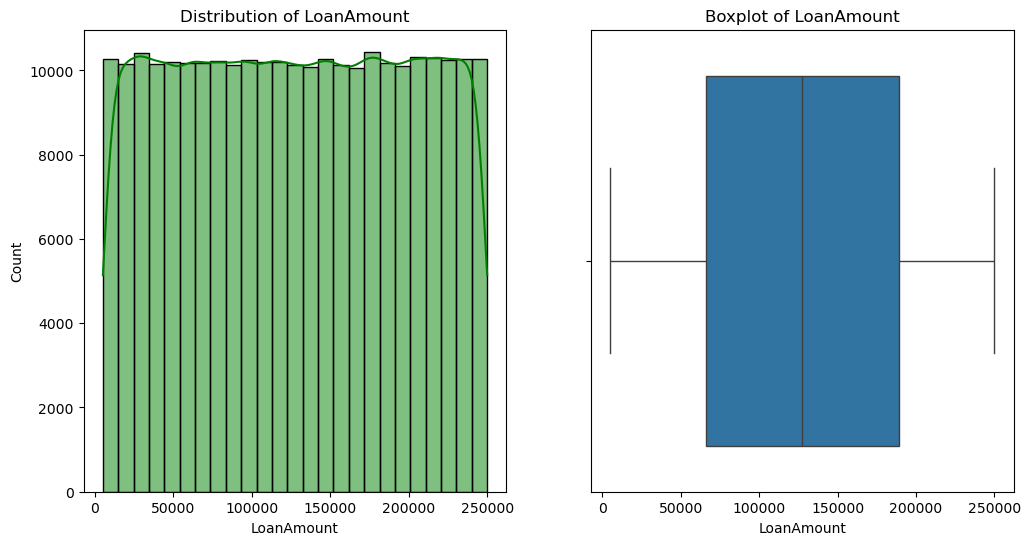

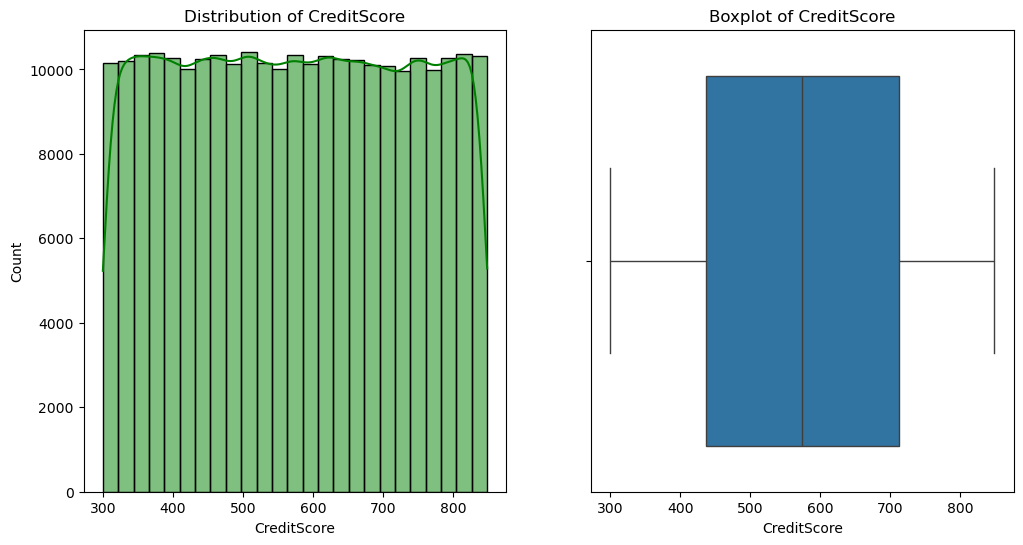

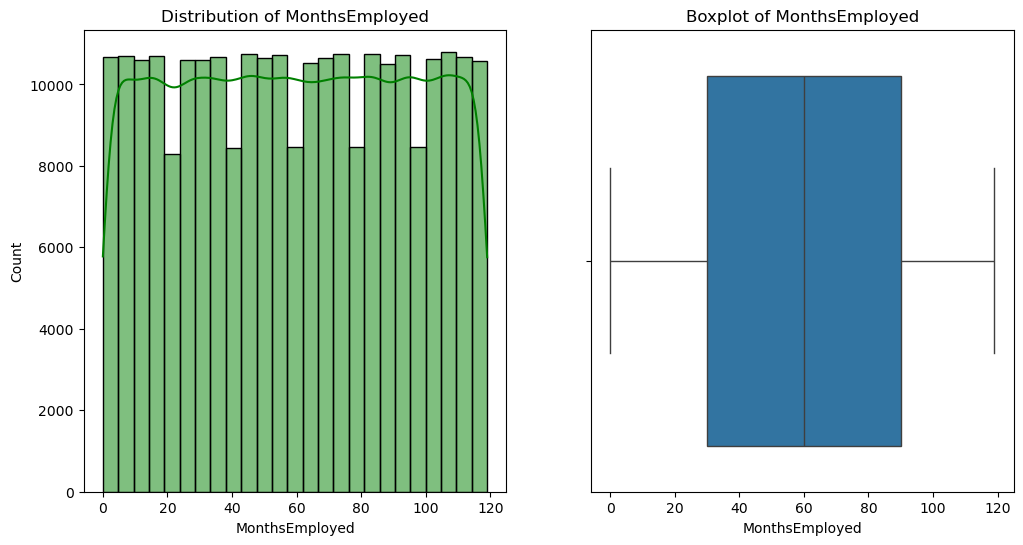

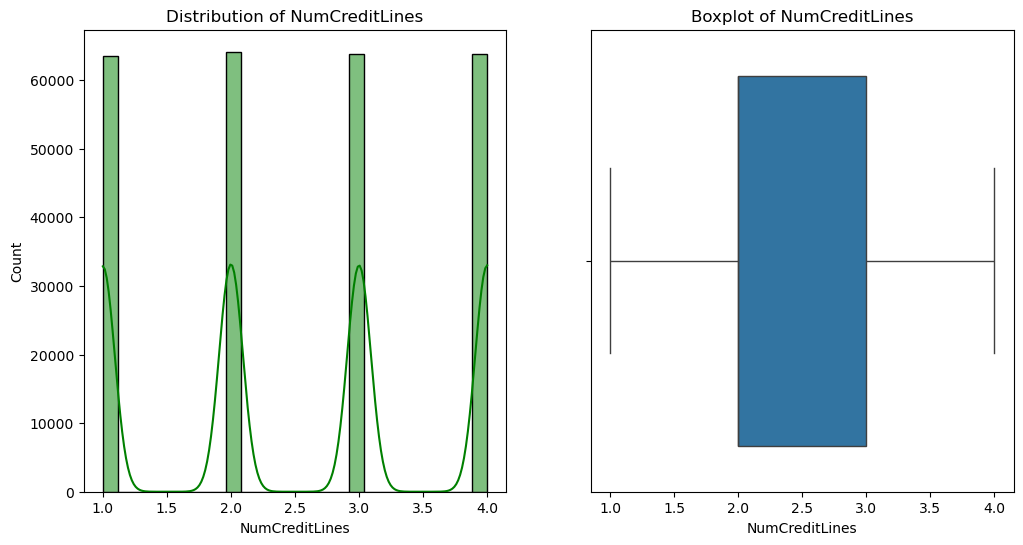

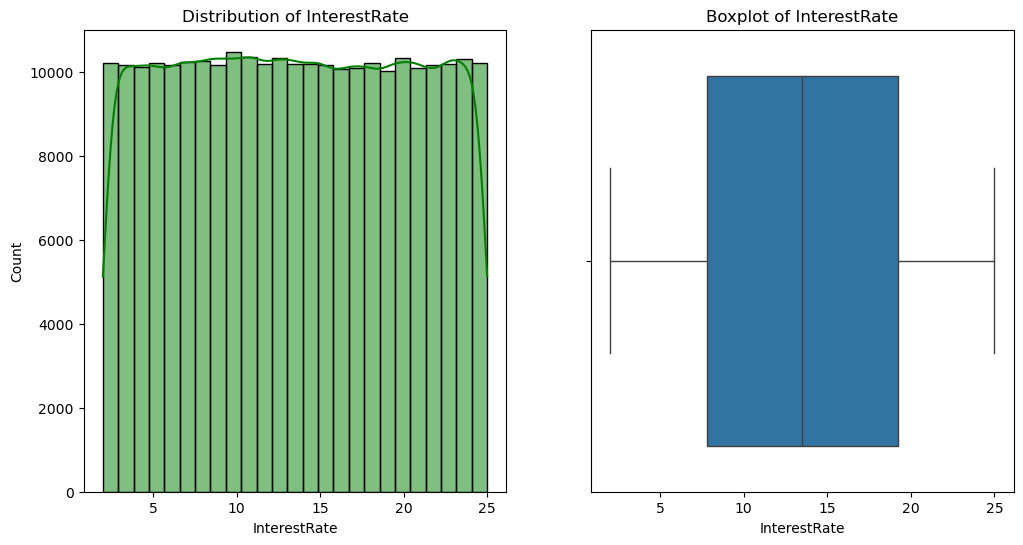

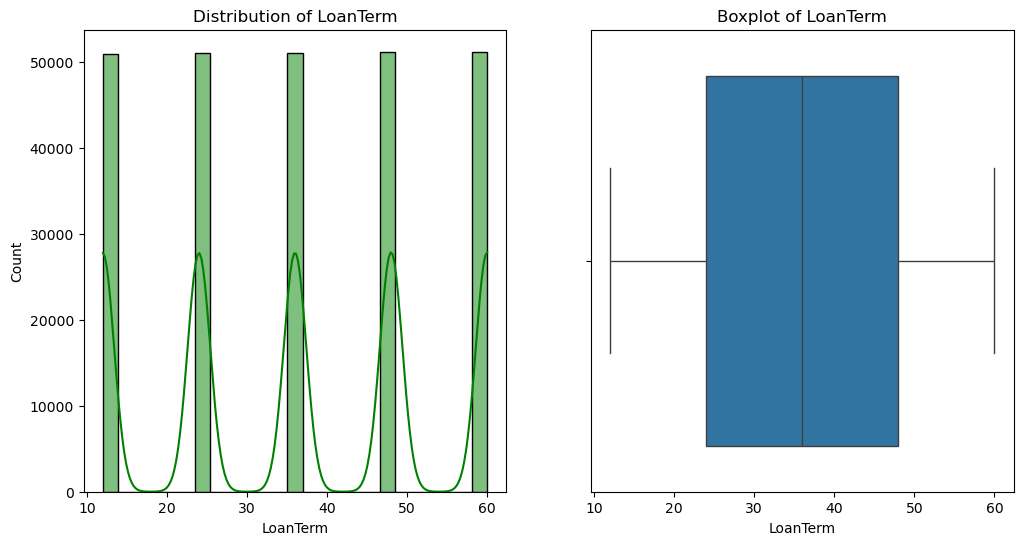

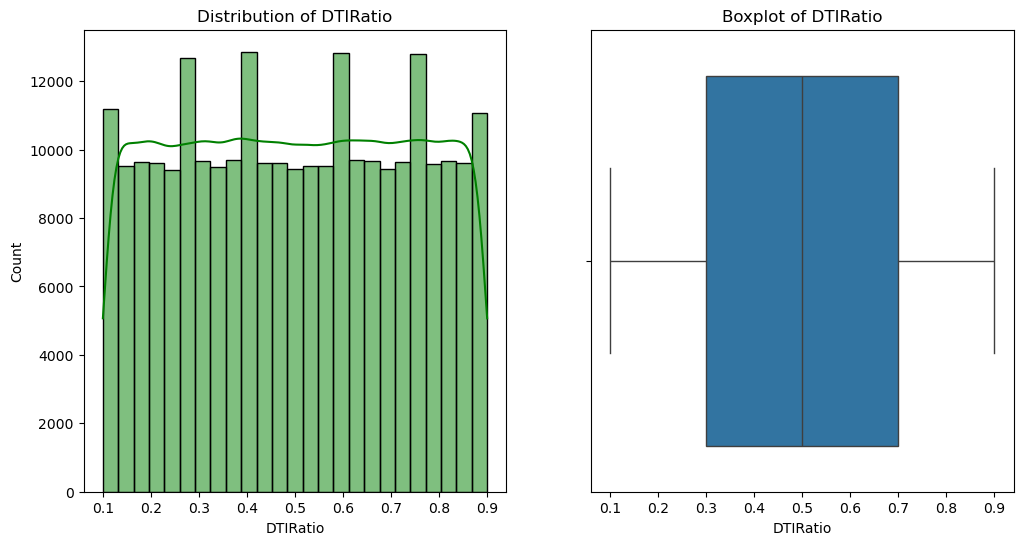

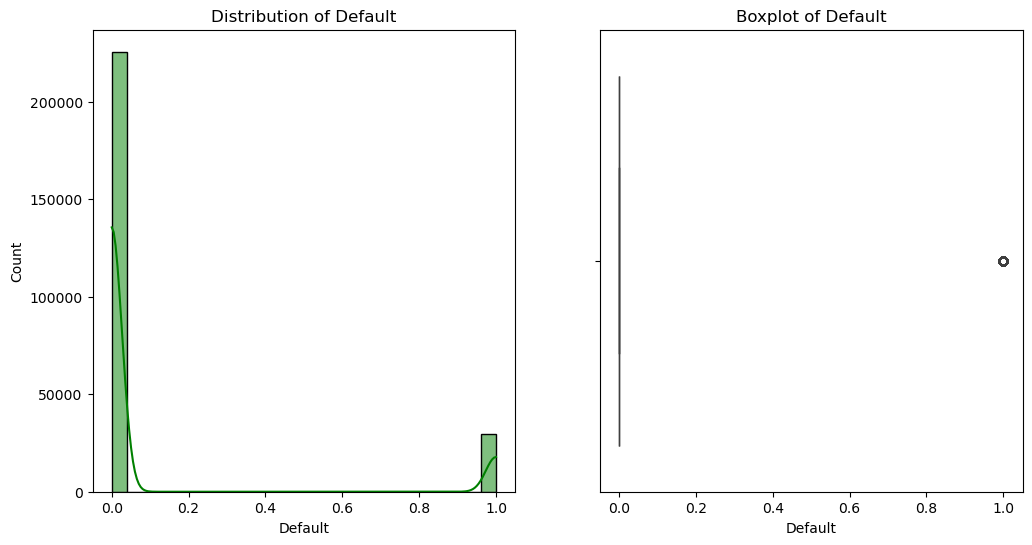

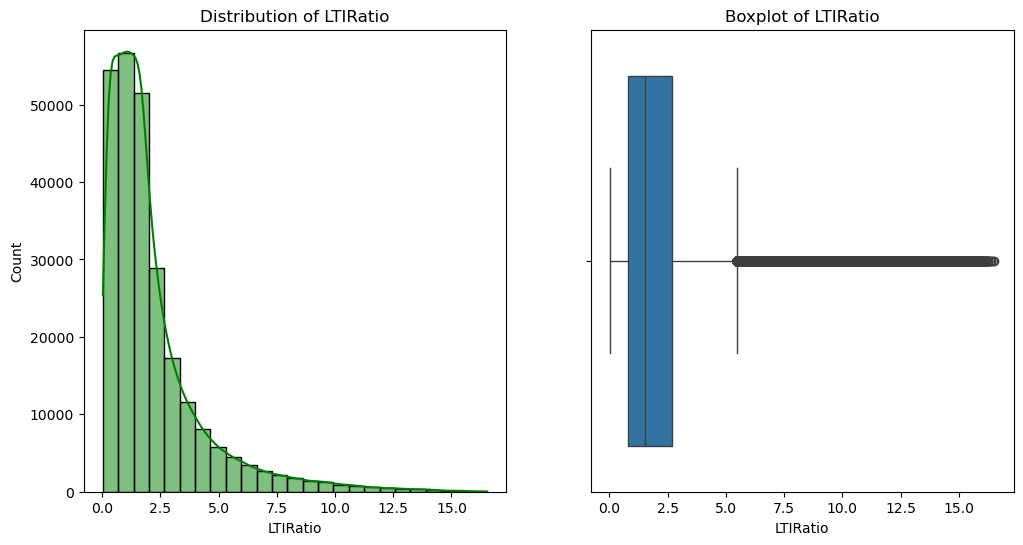

In [21]:
#Distribution of numerical columns

for col in num_cols:
    #Histogram
    plt.figure(figsize=(12,6))
    plt.subplot(1,2,1)
    sns.histplot(data=df[col],kde=True,bins=25,color='green')
    plt.title(f'Distribution of {col}')
    
    #Boxplot
    plt.subplot(1,2,2)
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

#### Correlation Matrix

In [22]:
corr = df[num_cols].corr()
corr

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default,LTIRatio
Age,1.000000,-0.001244,-0.002213,-0.000548,-0.000341,-0.000890,-0.001127,0.000263,-0.004689,-0.167783,-0.000343
Income,-0.001244,1.000000,-0.000865,-0.001430,0.002675,-0.002016,-0.002303,-0.000998,0.000205,-0.099119,-0.613392
LoanAmount,-0.002213,-0.000865,1.000000,0.001261,0.002817,0.000794,-0.002291,0.002538,0.001122,0.086659,0.554730
CreditScore,-0.000548,-0.001430,0.001261,1.000000,0.000613,0.000016,0.000436,0.001130,-0.001039,-0.034166,-0.000171
MonthsEmployed,-0.000341,0.002675,0.002817,0.000613,1.000000,0.001267,0.000096,-0.001166,0.001765,-0.097374,-0.001630
NumCreditLines,-0.000890,-0.002016,0.000794,0.000016,0.001267,1.000000,-0.000297,-0.000226,-0.000586,0.028330,0.000008
InterestRate,-0.001127,-0.002303,-0.002291,0.000436,0.000096,-0.000297,1.000000,0.000892,0.000575,0.131273,-0.000632
LoanTerm,0.000263,-0.000998,0.002538,0.001130,-0.001166,-0.000226,0.000892,1.000000,0.002273,0.000545,0.002196
DTIRatio,-0.004689,0.000205,0.001122,-0.001039,0.001765,-0.000586,0.000575,0.002273,1.000000,0.019236,0.000619
Default,-0.167783,-0.099119,0.086659,-0.034166,-0.097374,0.028330,0.131273,0.000545,0.019236,1.000000,0.178963


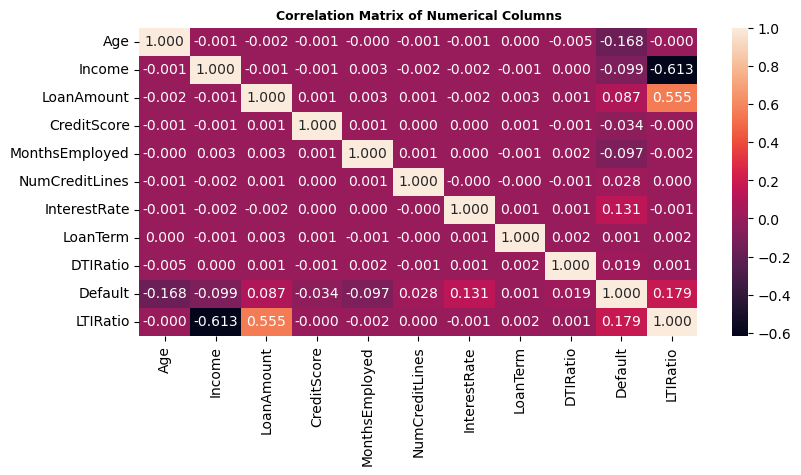

In [23]:
plt.figure(figsize=(9,4))
sns.heatmap(data=corr,fmt='.3f',linecolor='orange',annot=True)
plt.title(f'Correlation Matrix of Numerical Columns',fontweight='bold',fontsize=9)
plt.show()

#### Correlation Findings 

##### Statistical Independence & Key Signals
 - Complete Independence: Correlation coefficients near zero (0.001–0.002) confirm there is no linear relationship between features. The columns were generated to be entirely independent.
 - The Only Real Signals: Meaningful relationships only exist between the Default target and the engineered LTIRatio. Specifically, LTIRatio correlates at -0.61 with Income(strong negative) and 0.55 with LoanAmount(strong positive).

 - Why Is Almost Everything Zero?

 Simple — the dataset was synthetically generated. Each column was created using its own independent random generator, meaning no column was built with reference to another. 

In [24]:
for col in cat_cols:
    print(df[col].unique())

["Bachelor's" "Master's" 'High School' 'PhD']
['Full-time' 'Unemployed' 'Self-employed' 'Part-time']
['Divorced' 'Married' 'Single']
['Yes' 'No']
['Yes' 'No']
['Other' 'Auto' 'Business' 'Home' 'Education']
['Yes' 'No']
['Middle-Aged' 'Senior/Retiree' 'Adult' 'Young Adult']


In [25]:
#Feature vs Target Relationship -  a brief understanding of which features drive the "Default" Column
# For categorical:
pd.crosstab(df['EmploymentType'], df['Default'], normalize='index') * 100

Default,0,1
EmploymentType,,
Full-time,90.536634,9.463366
Part-time,88.034787,11.965213
Self-employed,88.537971,11.462029
Unemployed,86.447105,13.552895


<Axes: xlabel='Default', ylabel='CreditScore'>

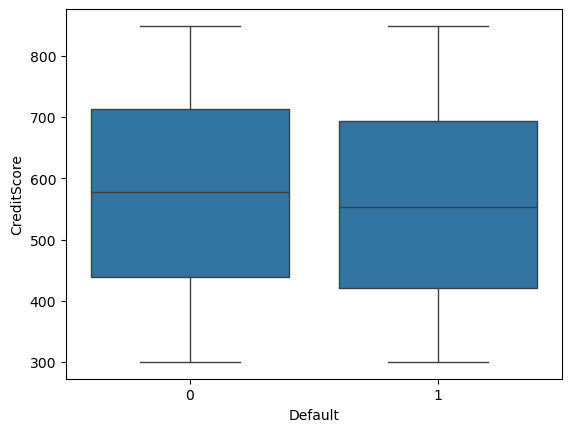

In [26]:
# For numerical:
sns.boxplot(x='Default', y='CreditScore', data=df)

<Axes: xlabel='Default', ylabel='DTIRatio'>

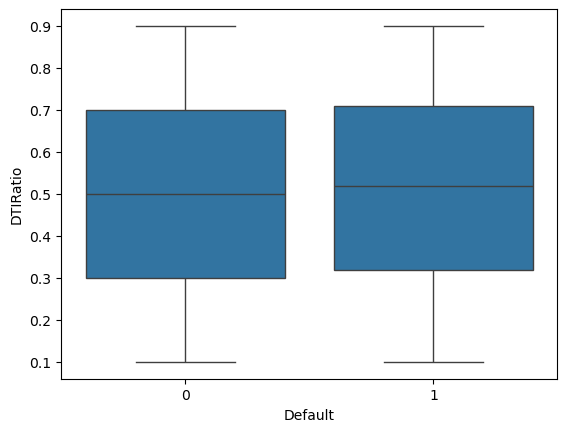

In [27]:
sns.boxplot(x='Default', y='DTIRatio', data=df)

In [28]:
months_zero = df['MonthsEmployed'] == 0
df_mask = df[months_zero]
df_mask.head()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default,LTIRatio,AgeGroup
3,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0,1.412638,Adult
53,43,70113,215064,657,0,2,6.00,24,0.76,Bachelor's,Self-employed,Single,No,Yes,Home,Yes,0,3.067391,Adult
242,49,39184,142572,533,0,2,9.43,60,0.35,High School,Full-time,Single,No,Yes,Auto,Yes,0,3.638526,Middle-Aged
330,52,40949,89073,371,0,2,3.69,12,0.66,Bachelor's,Self-employed,Single,No,Yes,Education,No,0,2.175218,Middle-Aged
348,68,91446,65709,653,0,4,21.77,60,0.28,Bachelor's,Part-time,Married,Yes,Yes,Auto,Yes,0,0.718555,Senior/Retiree


##### Logical Contradiction Found
Some applicants marked as Full-time or Part-time employed have 0 months of employment.

That makes no sense because if you are employed, you must have been employed for at least some months. Zero months employed but currently working is a straight-up contradiction.
This is just further proof that the dataset is 100% synthetic

In [29]:
features = ['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'Education',
'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner', 'LTIRatio', 'AgeGroup']
target = "Default"

In [30]:
#Splitting into training and testing sets
X = df[features]
y=df[target]

In [31]:
from sklearn.model_selection import train_test_split

In [32]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=42, stratify=y) #Due to class imbalance raio - 88 : 12

In [33]:
X_train.head()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,LTIRatio,AgeGroup
15826,45,37039,247916,624,19,2,4.62,60,0.85,High School,Unemployed,Married,No,Yes,Auto,No,6.693377,Adult
147371,48,133963,66275,494,119,3,14.72,48,0.49,PhD,Self-employed,Married,Yes,Yes,Other,Yes,0.494726,Middle-Aged
178180,47,100204,6967,718,108,3,5.51,24,0.76,High School,Self-employed,Single,Yes,Yes,Business,Yes,0.069528,Middle-Aged
126915,42,36078,25966,344,2,3,18.29,36,0.76,Bachelor's,Self-employed,Married,No,Yes,Education,No,0.719718,Adult
163930,20,99464,248557,318,74,3,19.45,60,0.45,Bachelor's,Part-time,Divorced,No,No,Auto,Yes,2.498964,Young Adult


In [34]:
y_train.head()

15826     0
147371    0
178180    0
126915    0
163930    1
Name: Default, dtype: int64

In [35]:
X_train.shape, X_test.shape

((204277, 18), (51070, 18))

In [36]:
y_train.shape, y_test.shape

((204277,), (51070,))

In [37]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer

In [38]:
#num_cols = ['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'LTIRatio']

#cat_cols = ['Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner', 'AgeGroup']

In [39]:
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include='object').columns.tolist()

In [40]:
num_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())])

cat_transformer = Pipeline(steps=[
    ('encoder', OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore'))])
#drop ='first' aims to remove redundancy,thereby forcing the model to be strictly logical and think.

In [41]:
preprocessor = ColumnTransformer(transformers=[
    ("num", num_transformer, num_cols),
    ("cat", cat_transformer, cat_cols)])

In [42]:
preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('scaler', StandardScaler())]),
                                 ['Age', 'Income', 'LoanAmount', 'CreditScore',
                                  'MonthsEmployed', 'NumCreditLines',
                                  'InterestRate', 'LoanTerm', 'DTIRatio',
                                  'LTIRatio']),
                                ('cat',
                                 Pipeline(steps=[('encoder',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['Education', 'EmploymentType',
                                  'MaritalStatus', 'HasMortgage',
                                  'HasDependents', 'LoanPurpose', 'HasCoSigner',
                                  'AgeGroup'])])

In [43]:
#Fit the preprocessor ONLY on X_train, then transform both train and test
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

##### BASELINE MODEL 
This baseline model is meant to serve as a benchmark(sort of a passmark), for the other models to be trained, to see if they generalised well with the training data and learnt patterns or they were just flirting around.

In [44]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Step 1: Train the Vanilla Baseline (No SMOTE applied yet)
# We train directly on the original imbalanced training set
vanilla_rf = RandomForestClassifier(random_state=42, n_jobs=-1)

print("Training Vanilla Random Forest on imbalanced data...")
vanilla_rf.fit(X_train_processed, y_train)

# Step 2: Make Predictions & Evaluate the unseen data
y_pred_vanilla = vanilla_rf.predict(X_test_processed)

print("=== VANILLA BASELINE (WITHOUT SMOTE) ===")

print(confusion_matrix(y_test, y_pred_vanilla))
print(accuracy_score(y_test, y_pred_vanilla))
print(classification_report(y_test, y_pred_vanilla, digits=4))

Training Vanilla Random Forest on imbalanced data...
=== VANILLA BASELINE (WITHOUT SMOTE) ===
[[44953   186]
 [ 5617   314]]
0.8863716467593499
              precision    recall  f1-score   support

           0     0.8889    0.9959    0.9394     45139
           1     0.6280    0.0529    0.0977      5931

    accuracy                         0.8864     51070
   macro avg     0.7585    0.5244    0.5185     51070
weighted avg     0.8586    0.8864    0.8416     51070



##### The Business Disaster that tends to occur if this baseline model is deployed without SMOTE
If a bank deployed this "Vanilla" model because it was excited about its 88.64% overall accuracy, it would have handed out 5,617 bad loans and lost millions of dollars. The model was essentially asleep at the wheel, approving 99.6% of applicants just to keep its overall accuracy high.

##### Why a Baseline Model is Necessary Before Applying SMOTE?

1. You Need Proof That SMOTE Actually Helped: In any experiment, you need a "control group" (the baseline) to prove that your "treatment" (SMOTE) actually did something useful. Without a baseline model trained on the original imbalanced data, there is nothing to compare against. You cannot claim SMOTE improved performance if you have no "before" score to reference.

2. The Baseline Exposes the Real Problem: Training on the raw 88:12 imbalanced data highlights the specific failure, which is the model’s inability to catch defaulters. This creates a benchmark score to beat.

3. Both Models Must Be Tested on the Same Data: The baseline and all SMOTE-trained models are evaluated on the exact same untouched test set. This ensures the comparison is fair,so any improvement seen after SMOTE is genuinely due to SMOTE, not a difference in test data.

In [45]:
y_train.value_counts()

Default
0    180555
1     23722
Name: count, dtype: int64

In [46]:
y_test.value_counts()

Default
0    45139
1     5931
Name: count, dtype: int64

#### The SMOTE technique

* What is SMOTE?
Synthetic Minority Over-sampling Technique —It is an algorithm that fixes class imbalance by generating new artificial data points for the minority class, rather than simply duplicating existing records.

* Why is it Being Used Here?
The dataset has an 88:12 class imbalance containing 88% non-defaulters and 12% defaulters. Without SMOTE, any machine learning model would quickly figure out that simply predicting no default for every single applicant yields about 88% accuracy without learning anything useful. That represents a failure disguised as a good score. SMOTE corrects this by balancing the classes, forcing the model to genuinely learn the patterns of actual defaulters rather than ignoring them entirely.

In [47]:
from imblearn.over_sampling import SMOTE

In [48]:
#Apply SMOTE ONLY to the training data to fix the 88:12 class imbalance
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_processed, y_train)

In [49]:
X_train_processed.shape

(204277, 28)

What SMOTE did here was calculate the exact difference between the majority and minority categories of the training set and generate 156,833 brand-new synthetic rows for Class 1, ensuring that when it finished, the training set had 180,555 rows of Class 0 and 180,555 rows of Class 1, resulting in a perfectly balanced 50/50 split totaling 361,110 training rows ready for the model.

In [50]:
X_train_resampled.shape

(361110, 28)

#### MODEL TRAINING

In [51]:
from sklearn.metrics import recall_score, precision_score, f1_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from lightgbm import LGBMClassifier

In [52]:
#Defining the models to train on SMOTE data
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "LightGBM": LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1)
}

In [ ]:
# Storing the results for side-by-side comparison 
results = []

# Adding the Vanilla Baseline results manually (Column names updated to match the loop!)
results.append({
    "Model": "Vanilla RF (Baseline)",
    "Accuracy Train": "-", 
    "Accuracy Test": 0.8864,
    "Precision Train": "-",
    "Precision Test": 0.6280,
    "Recall Train": "-",
    "Recall Test": 0.0529,
    "F1 Train": "-",
    "F1 Test": 0.0977,
    "ROC AUC Train": "-",
    "ROC AUC Test": "-"
})

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_resampled, y_train_resampled)

    # Making predictions 
    train_pred = model.predict(X_train_processed) 
    y_pred = model.predict(X_test_processed)
    
    # Calculating probabilities for ROC AUC
    train_prob = model.predict_proba(X_train_processed)[:, 1]
    test_prob = model.predict_proba(X_test_processed)[:, 1]

    # Appending the results to our list
    results.append({
        "Model": name,
        "Accuracy Train": round(accuracy_score(y_train, train_pred), 4),
        "Accuracy Test": round(accuracy_score(y_test, y_pred), 4),
        "Precision Train": round(precision_score(y_train, train_pred, zero_division=0), 4),
        "Precision Test": round(precision_score(y_test, y_pred, zero_division=0), 4),
        "Recall Train": round(recall_score(y_train, train_pred, zero_division=0), 4),
        "Recall Test": round(recall_score(y_test, y_pred, zero_division=0), 4),
        "F1 Train": round(f1_score(y_train, train_pred, zero_division=0), 4),
        "F1 Test": round(f1_score(y_test, y_pred, zero_division=0), 4),
        "ROC AUC Train": round(roc_auc_score(y_train, train_prob), 4),
        "ROC AUC Test": round(roc_auc_score(y_test, test_prob), 4)
    })

In [54]:
results

[{'Model': 'Vanilla RF (Baseline)',
  'Accuracy Train': '-',
  'Accuracy Test': 0.8864,
  'Precision Train': '-',
  'Precision Test': 0.628,
  'Recall Train': '-',
  'Recall Test': 0.0529,
  'F1 Train': '-',
  'F1 Test': 0.0977,
  'ROC AUC Train': '-',
  'ROC AUC Test': '-'},
 {'Model': 'Logistic Regression',
  'Accuracy Train': 0.693,
  'Accuracy Test': 0.6927,
  'Precision Train': np.float64(0.2267),
  'Precision Test': np.float64(0.2289),
  'Recall Train': np.float64(0.6817),
  'Recall Test': np.float64(0.6947),
  'F1 Train': np.float64(0.3402),
  'F1 Test': np.float64(0.3443),
  'ROC AUC Train': np.float64(0.7551),
  'ROC AUC Test': np.float64(0.7609)},
 {'Model': 'Decision Tree',
  'Accuracy Train': 1.0,
  'Accuracy Test': 0.7881,
  'Precision Train': np.float64(1.0),
  'Precision Test': np.float64(0.1981),
  'Recall Train': np.float64(1.0),
  'Recall Test': np.float64(0.2708),
  'F1 Train': np.float64(1.0),
  'F1 Test': np.float64(0.2288),
  'ROC AUC Train': np.float64(1.0),
  'R

In [56]:
# Convert results to a clean summary table
comparison_df = pd.DataFrame(results)
comparison_df

,Model,Accuracy Train,Accuracy Test,Precision Train,Precision Test,Recall Train,Recall Test,F1 Train,F1 Test,ROC AUC Train,ROC AUC Test
0,Vanilla RF (Baseline),-,0.8864,-,0.6280,-,0.0529,-,0.0977,-,-
1,Logistic Regression,0.693,0.6927,0.2267,0.2289,0.6817,0.6947,0.3402,0.3443,0.7551,0.7609
2,Decision Tree,1.0,0.7881,1.0,0.1981,1.0,0.2708,1.0,0.2288,1.0,0.5634
3,Random Forest,1.0,0.8817,1.0,0.4632,1.0,0.1177,1.0,0.1877,1.0,0.738
4,Gradient Boosting,0.8801,0.8804,0.4504,0.4558,0.1473,0.1538,0.222,0.2300,0.7497,0.7499
5,LightGBM,0.8876,0.8860,0.6548,0.5925,0.068,0.0588,0.1231,0.1071,0.7664,0.7569


##### Model Performance Summary
**Logistic Regression: Strong Generalization & High Recall**
Train recall (68.17%) and test recall (69.47%) match almost identically, showing it learned genuine default patterns rather than memorizing data. Catching nearly 70% of bad loans offers immediate financial protection.

**Decision Tree & Random Forest: Severe Overfitting on Synthetic Data**
Both hit 100% recall on training data but collapsed on unseen test data. They simply memorized the artificial SMOTE points instead of learning real-world risk behaviors.

**Gradient Boosting & LightGBM: Trapped in the Accuracy Paradox**
These models largely ignored the SMOTE resampling and reverted to predicting non-defaulters, leaving test recall under 16% despite high overall accuracy.

Conclusion: Logistic Regression is the best deployable model. It trades overall accuracy to successfully maximize the detection of loan defaulters without overfitting.

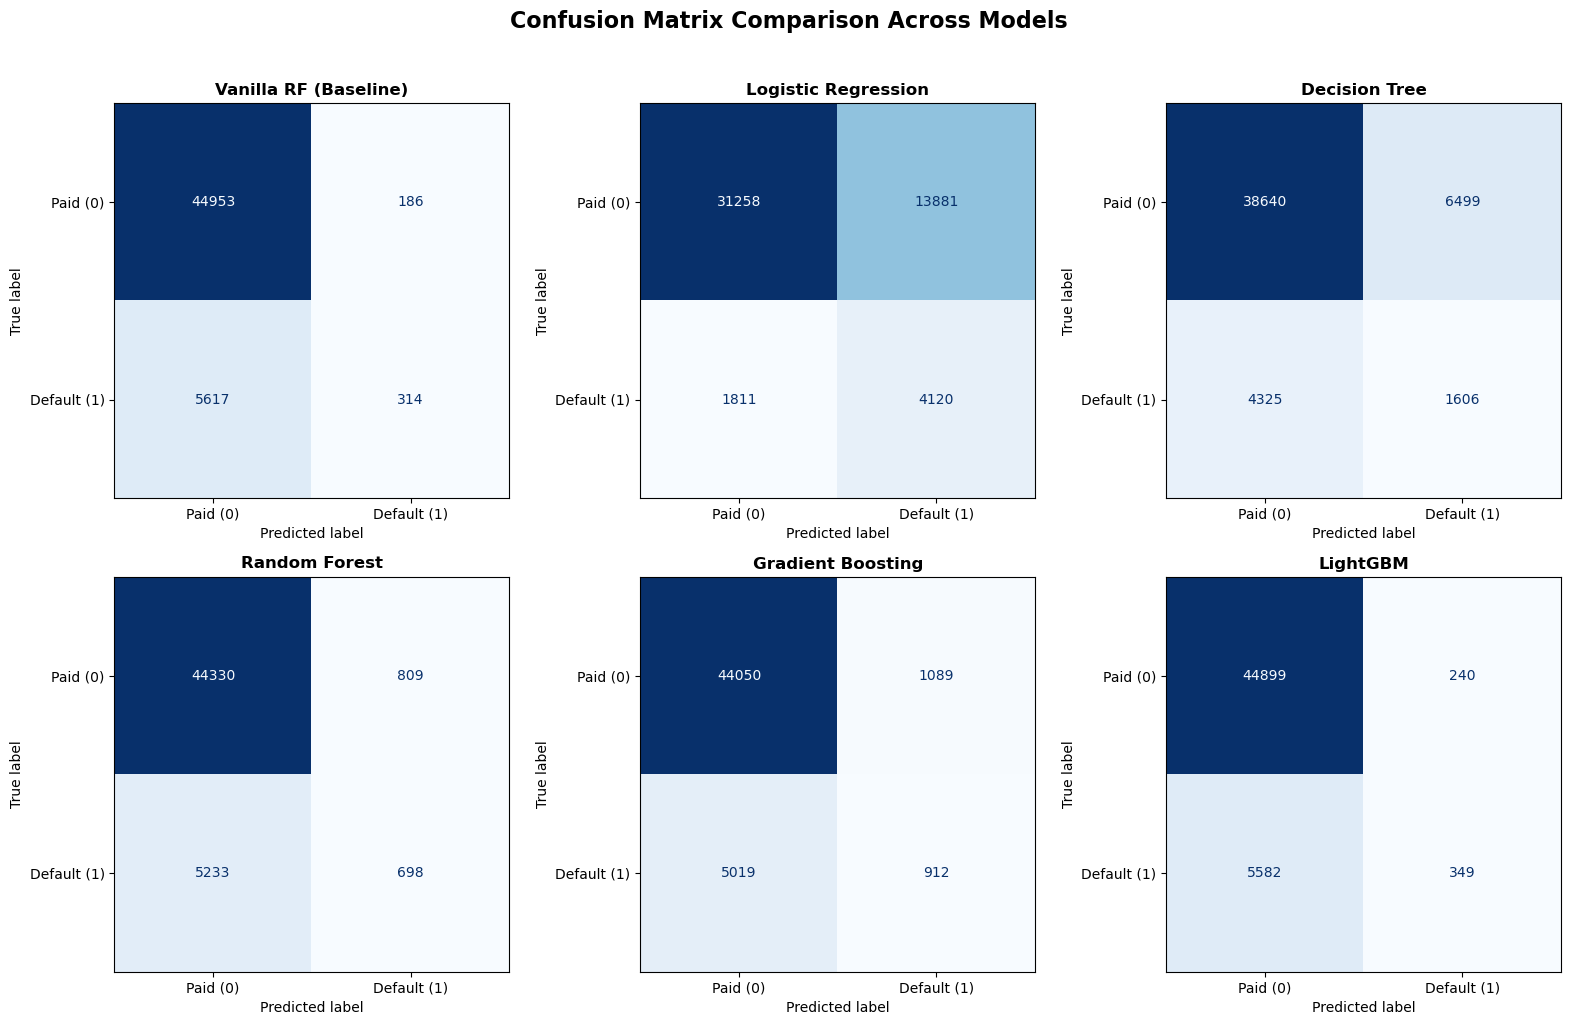

In [58]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# Combine Vanilla Baseline and SMOTE models into one dictionary
all_eval_models = {
    "Vanilla RF (Baseline)": vanilla_rf,
    **models
}

# Set up a 2x3 grid for plotting
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, (name, model) in enumerate(all_eval_models.items()):
    # Predict on test set
    y_pred = model.predict(X_test_processed)
    
    # Generate confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    
    # Display plot
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Paid (0)", "Default (1)"])
    disp.plot(ax=axes[i], cmap="Blues", colorbar=False)
    axes[i].set_title(name, fontsize=12, fontweight="bold")
    axes[i].grid(False)

# Hide any empty subplots if grid has unused spaces
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Confusion Matrix Comparison Across Models", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()